# Churn Model — XGBoost on the Gold Feature Table

EDA and training for the churn classifier.

Features come from the dbt-built gold table `analytics.customer_features` — this
notebook does **not** compute production features. It does model-specific prep,
trains XGBoost, tunes the decision threshold, evaluates, and (section 8)
explores candidate features. Shared logic is imported from `backend.ml`.

**Prerequisite:** the pipeline has been run (`docker compose up -d`, the loader,
the simulation, `dbt build`) so the gold table exists.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score

from backend.db.session import engine
from backend.ml.data import load_gold, load_splits
from backend.ml.train import build_model, evaluate, tune_threshold, PARAMS

pd.set_option("display.max_columns", None)

c:\Users\Justin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the gold table

In [2]:
df = load_gold()

# numeric columns arrive from Postgres as Decimal — coerce for analysis
keys = {"customer_unique_id", "snapshot_date", "customer_state", "churned", "split"}
num = [c for c in df.columns if c not in keys]
df[num] = df[num].apply(pd.to_numeric)

print(f"{len(df):,} rows  -  {df.shape[1]} columns")
df.head()

18,618 rows  -  22 columns


,customer_unique_id,snapshot_date,customer_state,frequency,recency_days,tenure_days,monetary_total,monetary_avg,avg_items_per_order,avg_freight_value,avg_review_score,review_count,avg_delivery_days,avg_payment_types,avg_installments,avg_sellers_per_order,avg_categories_per_order,order_interval_mean,order_interval_std,order_interval_median,churned,split
0,b3dec7c277aa6dc3286018616ac9322c,2017-08-01,RS,1,93,0,37.79,37.79,1.0,20.80,5.0,1,10.724109,1.0,1.0,1.0,1.0,NaN,NaN,NaN,False,train
1,e4f070f3f5040d33b674942b4b42ef03,2017-08-01,MG,1,50,0,44.38,44.38,1.0,12.48,5.0,1,6.929873,1.0,1.0,1.0,1.0,NaN,NaN,NaN,False,train
2,7cbf84875196ee1d04dc880ebbfaa7ef,2017-08-01,SP,1,48,0,216.82,216.82,2.0,19.02,5.0,1,7.788588,1.0,1.0,1.0,1.0,NaN,NaN,NaN,False,train
3,2578106ae970e17713754c048abd07e4,2017-08-01,SP,1,69,0,137.70,137.70,1.0,9.71,5.0,1,1.746053,1.0,1.0,1.0,1.0,NaN,NaN,NaN,False,train
4,e54b6227976d874df531fc27efc726db,2017-08-01,GO,1,173,0,173.09,173.09,1.0,29.29,5.0,1,12.733553,1.0,1.0,1.0,1.0,NaN,NaN,NaN,False,train


## 2. Churn balance and the train/test/validation split

The `split` column is assigned deterministically in dbt and stratified by the
churn label — so every split carries the same churn rate.

overall churn rate: 0.803


,rows,churn_rate
split,,
test,2777,0.805
train,13066,0.802
validation,2775,0.805


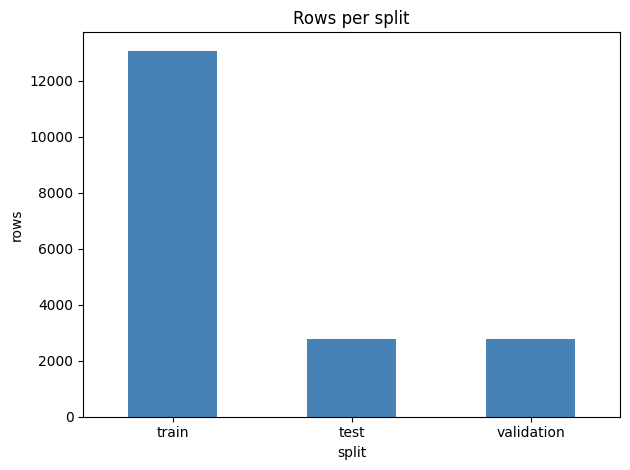

In [3]:
print("overall churn rate:", round(df["churned"].mean(), 3))

summary = df.groupby("split").agg(
    rows=("churned", "size"),
    churn_rate=("churned", "mean"),
).round(3)
display(summary)

summary["rows"].reindex(["train", "test", "validation"]).plot.bar(
    color="steelblue", title="Rows per split", rot=0)
plt.ylabel("rows"); plt.tight_layout(); plt.show()

## 3. Do the features separate churned from retained customers?

If the synthetic augmentation worked, retained customers should show better
first-order experiences (higher review score, faster delivery).

In [4]:
signal = ["avg_review_score", "avg_delivery_days", "frequency",
          "recency_days", "monetary_avg", "order_interval_mean"]
df.groupby("churned")[signal].mean().round(2)

,avg_review_score,avg_delivery_days,frequency,recency_days,monetary_avg,order_interval_mean
churned,,,,,,
False,4.81,9.46,1.28,57.60,149.50,45.76
True,3.88,13.66,1.19,84.59,164.48,43.47


## 4. Prepare the splits and train

`load_splits()` reads the gold table, splits by the `split` column, and applies
leakage-free prep. `build_model()` sets `scale_pos_weight` from the class
balance.

In [5]:
splits, feature_cols = load_splits()
X_train, y_train = splits["train"]
X_test,  y_test  = splits["test"]
X_val,   y_val   = splits["validation"]

print(f"features: {len(feature_cols)}  -  "
      f"train: {len(y_train):,}   test: {len(y_test):,}   val: {len(y_val):,}")

model = build_model(y_train)
model.fit(X_train, y_train)
print("scale_pos_weight:", round(model.scale_pos_weight, 3))

features: 18  -  train: 13,066   test: 2,777   val: 2,775
scale_pos_weight: 0.247


## 5. Tune the decision threshold, then evaluate

The model outputs probabilities; precision and recall depend on the cutoff. The
default 0.5 catches only ~67% of churners. We tune the threshold on the
**validation** PR curve — the highest-precision threshold that still catches
**85%** of churners — then evaluate at it.

(An F-beta objective collapses here: churn is the ~80% majority class, so
"predict everyone" maximises it. Test is held out from tuning, so its numbers
are unbiased.)

In [6]:
threshold = tune_threshold(model, X_val, y_val)   # recall >= 0.85 on validation
print(f"tuned threshold: {threshold:.3f}   (default was 0.5)")

pd.DataFrame({
    "test @0.50":        evaluate(model, X_test, y_test, 0.5),
    "test @tuned":       evaluate(model, X_test, y_test, threshold),
    "validation @tuned": evaluate(model, X_val, y_val, threshold),
}).round(3)

tuned threshold: 0.329   (default was 0.5)


,test @0.50,test @tuned,validation @tuned
roc_auc,0.791,0.791,0.798
pr_auc,0.942,0.942,0.938
precision,0.920,0.865,0.878
recall,0.668,0.855,0.852
f1,0.774,0.860,0.865
brier,0.181,0.181,0.179


## 6. ROC and precision-recall curves (validation)

The tuned operating point is marked on the PR curve; the dotted line is the
0.80 churn base rate (the precision a "predict everyone" classifier gets).

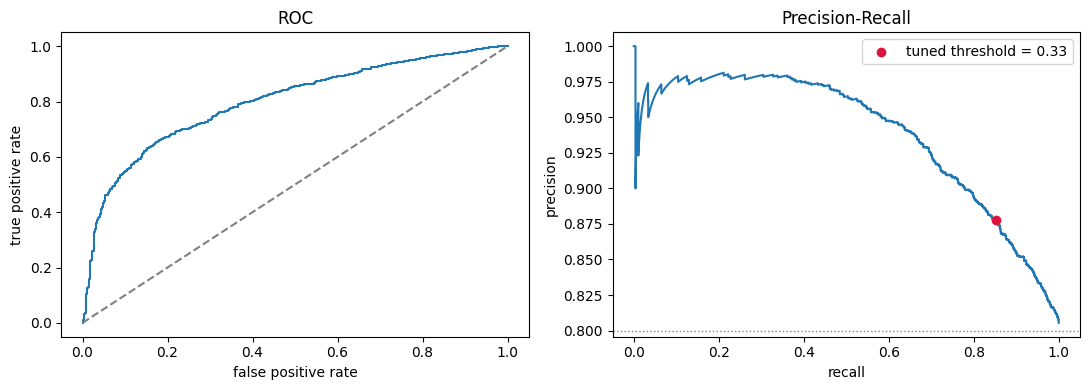

In [7]:
proba = model.predict_proba(X_val)[:, 1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

fpr, tpr, _ = roc_curve(y_val, proba)
a1.plot(fpr, tpr); a1.plot([0, 1], [0, 1], "--", c="grey")
a1.set(title="ROC", xlabel="false positive rate", ylabel="true positive rate")

prec, rec, _ = precision_recall_curve(y_val, proba)
a2.plot(rec, prec)
op = evaluate(model, X_val, y_val, threshold)
a2.scatter([op["recall"]], [op["precision"]], color="crimson", zorder=5,
           label=f"tuned threshold = {threshold:.2f}")
a2.axhline(0.80, ls=":", c="grey", lw=1)
a2.legend()
a2.set(title="Precision-Recall", xlabel="recall", ylabel="precision")

plt.tight_layout(); plt.show()

## 7. Feature importance

A sanity check on the pipeline: the synthetic generator drove reorder behaviour
from review score and delivery speed, so those should dominate.

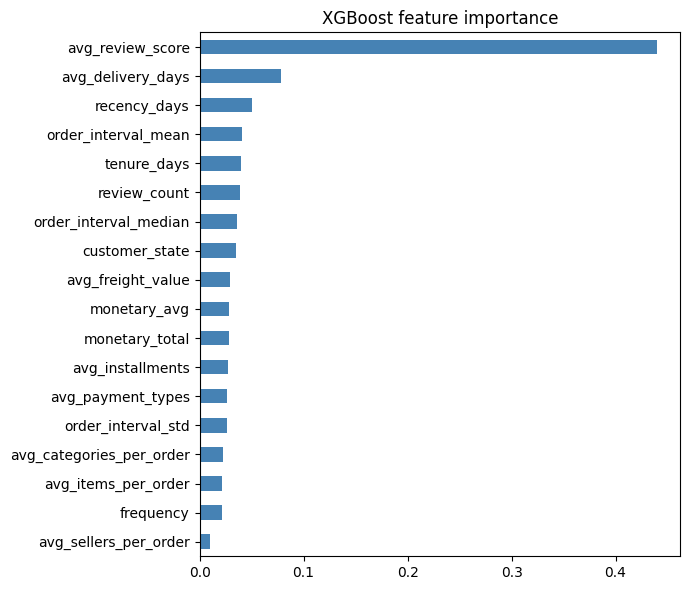

In [8]:
imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
imp.plot.barh(figsize=(7, 6), color="steelblue",
              title="XGBoost feature importance")
plt.tight_layout(); plt.show()

## 8. Feature exploration — which candidate features are worth adding?

Before adding columns to the dbt gold model, test whether candidate features
actually separate churned from retained customers.

These candidates do not exist in the gold table yet, so they are computed here
**from the order-level data** (`int_customer_orders` joined to `stg_orders`),
using the same point-in-time cutoff the gold table uses (orders on or before
the snapshot date). This is exploration only — anything that earns its place
gets promoted to SQL in the dbt model.

In [9]:
SNAPSHOT = pd.Timestamp("2017-08-01")

orders = pd.read_sql('''
    select co.customer_unique_id, co.order_id, co.order_status,
           co.order_purchase_timestamp, co.delivery_days, co.review_score,
           so.order_estimated_delivery_date, so.order_delivered_customer_date
    from analytics.int_customer_orders co
    join analytics.stg_orders so using (order_id)
''', engine)

# point-in-time: history on/before the snapshot, the cutoff the gold table uses
orders = orders[orders["order_purchase_timestamp"] <= SNAPSHOT].copy()
orders["days_late"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

print(f"{len(orders):,} historical orders  -  "
      f"{orders.customer_unique_id.nunique():,} customers")

22,239 historical orders  -  18,459 customers


In [10]:
ordered = orders.sort_values("order_purchase_timestamp")

agg = ordered.groupby("customer_unique_id").agg(
    n_orders=("order_id", "size"),
    avg_days_late=("days_late", "mean"),
    late_rate=("days_late", lambda s: (s > 0).mean()),
    trouble_rate=("order_status", lambda s: (s != "delivered").mean()),
    review_rate=("review_score", lambda s: s.notna().mean()),
    first_review=("review_score", "first"),
    last_review=("review_score", "last"),
    first_delivery=("delivery_days", "first"),
    last_delivery=("delivery_days", "last"),
    first_ts=("order_purchase_timestamp", "first"),
    last_ts=("order_purchase_timestamp", "last"),
)
agg["review_trend"]   = agg["last_review"] - agg["first_review"]
agg["delivery_trend"] = agg["last_delivery"] - agg["first_delivery"]
agg["tenure_days"]    = (agg["last_ts"] - agg["first_ts"]).dt.days
agg["order_rate"]     = agg["n_orders"] / agg["tenure_days"].clip(lower=1)
agg.head()

,n_orders,avg_days_late,late_rate,trouble_rate,review_rate,first_review,last_review,first_delivery,last_delivery,first_ts,last_ts,review_trend,delivery_trend,tenure_days,order_rate
customer_unique_id,,,,,,,,,,,,,,,
0000f46a3911fa3c0805444483337064,1,-1.389734,0.0,0.0,1.0,3.0,3.0,25.731759,25.731759,2017-03-10 21:05:03,2017-03-10 21:05:03,0.0,0.000000,0,1.000000
0005e1862207bf6ccc02e4228effd9a0,2,-22.770428,0.0,0.0,1.0,4.0,5.0,4.375648,6.102801,2017-03-04 23:32:12,2017-04-29 16:39:40,1.0,1.727153,55,0.036364
0006fdc98a402fceb4eb0ee528f6a8d4,1,-11.220266,0.0,0.0,1.0,3.0,3.0,16.388646,16.388646,2017-07-18 09:23:10,2017-07-18 09:23:10,0.0,0.000000,0,1.000000
0010a452c6d13139e50b57f19f52e04e,1,-18.552396,0.0,0.0,1.0,1.0,1.0,14.973495,14.973495,2017-07-11 11:22:43,2017-07-11 11:22:43,0.0,0.000000,0,1.000000
00115fc7123b5310cf6d3a3aa932699e,2,-24.467095,0.0,0.0,1.0,4.0,4.0,10.999317,7.150810,2017-01-21 21:58:35,2017-04-03 16:50:08,0.0,-3.848507,71,0.028169


In [11]:
# join the gold churn label, then score each candidate's discriminative power
gold = df.set_index("customer_unique_id")
explore = agg.join(gold[["churned", "recency_days", "order_interval_median"]], how="inner")
explore["overdue_ratio"] = explore["recency_days"] / explore["order_interval_median"]

candidates = ["avg_days_late", "late_rate", "trouble_rate", "review_rate",
              "last_review", "review_trend", "last_delivery", "delivery_trend",
              "overdue_ratio", "order_rate"]

y = explore["churned"].astype(int)
rows = []
for c in candidates:
    s = pd.to_numeric(explore[c], errors="coerce")
    mask = s.notna() & np.isfinite(s)
    if mask.sum() < 50 or s[mask].nunique() < 2:
        continue
    auc = roc_auc_score(y[mask], s[mask])
    rows.append({
        "feature": c,
        "discriminative_AUC": round(max(auc, 1 - auc), 3),
        "mean_retained": round(float(s[mask & (y == 0)].mean()), 2),
        "mean_churned": round(float(s[mask & (y == 1)].mean()), 2),
        "coverage": round(float(mask.mean()), 2),
    })

pd.DataFrame(rows).sort_values("discriminative_AUC", ascending=False).reset_index(drop=True)

,feature,discriminative_AUC,mean_retained,mean_churned,coverage
0,last_review,0.705,4.76,3.85,0.99
1,last_delivery,0.648,9.80,13.86,0.96
2,overdue_ratio,0.570,2.47,3.59,0.16
3,order_rate,0.536,0.82,0.88,1.00
4,trouble_rate,0.524,0.01,0.06,1.00
5,late_rate,0.523,0.01,0.05,1.00
6,avg_days_late,0.521,-14.08,-13.05,0.96
7,delivery_trend,0.518,0.68,0.42,0.96
8,review_trend,0.512,-0.10,-0.07,0.99
9,review_rate,0.505,0.99,0.99,1.00


### What to do with this

`discriminative_AUC` is each candidate's single-feature, direction-agnostic
separation of churned vs retained (0.50 = no signal). Candidates clearly above
0.50 — and with reasonable `coverage` — earn a place in the **dbt gold model**:
added as SQL in `customer_features.sql` (and `int_customer_orders.sql` for
`days_late`, which needs the estimated delivery date). Candidates near 0.50, or
sparse, are not worth the column.

Feature engineering stays in dbt — this notebook only *tests* candidates.

## 9. Reproducible run and MLflow tracking

This notebook is for exploration. The **reproducible** training run lives in
`src/backend/ml/train.py`, which trains, tunes the threshold, logs
parameters/metrics/importance, and **registers** the model to `logs/mlruns/`:

```
python -m backend.ml.train
```

Browse the tracked runs with `mlflow ui` from the repo root.